In [ ]:
import geopandas as gpd
import pandas as pd

basline_blocks = gpd.read_file('data/leningrad_oblast/ gatchina/blocks_agg.geojson')
basline_blocks.head()

DataSourceError: ./data/gatchina/blocks_agg_with_indicators.geojson: No such file or directory

In [2]:
basline_blocks.loc[142]

residential                                                         1.0
business                                                            0.0
recreation                                                          0.0
industrial                                                          0.0
transport                                                           0.0
special                                                             0.0
agriculture                                                         0.0
land_use                                            LandUse.RESIDENTIAL
share                                                               1.0
footprint_area                                              1568.375787
build_floor_area                                            1568.375787
living_area                                                 1202.729596
non_living_area                                              365.646192
population                                                      

In [3]:
from catboost import CatBoostRegressor
model = CatBoostRegressor()
model.load_model('./data/catboost_land_value_no_services.cbm')  # модель на лог-цене
print(len(model.feature_names_))

101


In [4]:
feature_cols = [
'residential','business','recreation','industrial','transport','special',
'agriculture','land_use','share','footprint_area','build_floor_area',
'living_area','non_living_area','population','site_area','fsi','gsi',
'mxi','l','morphotype','area_accessibility'
]
cat_features = ['land_use', 'morphotype']
numeric_feats = [c for c in feature_cols if c not in cat_features]
basline_blocks["id"] = basline_blocks.index

In [5]:
basline_blocks['residential'] = basline_blocks['residential'].astype('float64')

In [6]:
# import geopandas as gpd
# import pandas as pd

# # 1. Переводим в метрическую CRS
# baseline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()

# # 2. Считаем площадь в м2 и гектарах
# baseline_blocks_metric["calc_area_m2"] = baseline_blocks_metric.geometry.area
# baseline_blocks_metric["calc_area_ha"] = baseline_blocks_metric["calc_area_m2"] / 10_000

# # 3. Переводим site_area в гектары
# baseline_blocks_metric["site_area_ha"] = baseline_blocks_metric["site_area"] / 10_000

# # 4. Сравниваем
# baseline_blocks_metric["area_diff_ha"] = (
#     baseline_blocks_metric["calc_area_ha"] - baseline_blocks_metric["site_area_ha"]
# )

# baseline_blocks_metric["area_diff_pct"] = (
#     baseline_blocks_metric["area_diff_ha"] / baseline_blocks_metric["site_area_ha"] * 100
# )

# # 5. Сводка
# print(
#     baseline_blocks_metric[
#         ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct"]
#     ].describe()
# )

# # 6. Самые большие расхождения
# comparison_ha = baseline_blocks_metric[
#     ["site_area_ha", "calc_area_ha", "area_diff_ha", "area_diff_pct", "geometry"]
# ].copy()

# comparison_ha["abs_area_diff_pct"] = comparison_ha["area_diff_pct"].abs()
# comparison_ha.sort_values("abs_area_diff_pct", ascending=False).head(10)


In [7]:
# удаляем старую колонку
basline_blocks = basline_blocks.drop(columns=["site_area"], errors="ignore").copy()

# пересчитываем площадь в метрической CRS
basline_blocks_metric = basline_blocks.to_crs(basline_blocks.estimate_utm_crs()).copy()
basline_blocks["site_area"] = basline_blocks_metric.geometry.area.values


In [8]:
from urbanomy.methods.land_value_modeling import LandPriceEstimator

estimator = LandPriceEstimator(
    model=model,
    orig_features=numeric_feats+cat_features,
    categorical_features=cat_features,
    blocks=basline_blocks, #or blocks_198
)
blocks_pred = estimator.predict()
blocks_pred.head()


,residential,business,recreation,industrial,transport,special,agriculture,land_use,share,footprint_area,...,fsi,gsi,mxi,l,morphotype,area_accessibility,geometry,id,site_area,land_value
0,0.690207,0.211718,0.055976,0.0,0.042093,0.0,0.0,LandUse.RESIDENTIAL,0.690207,7383.849525,...,0.012109,0.008829,0.091908,1.371459,individual residential,10.063987,"POLYGON ((30.09367 59.55207, 30.09375 59.55215...",0,215420.389645,4.523965e+08
1,0.970519,0.029484,0.000000,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.970519,15304.958732,...,0.212156,0.036428,0.712492,5.824002,mid-rise,10.210398,"POLYGON ((30.09448 59.56164, 30.09448 59.56164...",1,108166.972589,6.273598e+08
2,0.936589,0.010562,0.052849,0.0,0.000000,0.0,0.0,LandUse.RESIDENTIAL,0.936589,17141.628200,...,0.303551,0.056576,0.786029,5.365401,mid-rise,8.669212,"POLYGON ((30.12546 59.58002, 30.12541 59.57998...",2,77911.495727,5.809435e+08
3,0.121353,0.819171,0.059489,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.819171,9453.530183,...,0.173716,0.075903,0.198114,2.288643,low-rise model,7.467434,"POLYGON ((30.12501 59.56588, 30.12497 59.56582...",3,32058.270586,1.065881e+08
4,0.068737,0.931312,0.000000,0.0,0.000000,0.0,0.0,LandUse.BUSINESS,0.931312,8567.309559,...,0.156696,0.071648,0.095598,2.187029,low-rise model,8.285434,"POLYGON ((30.1249 59.56574, 30.12497 59.56582,...",4,30779.356283,8.802486e+07


count       333.000000
mean     362550.398065
std      166120.451087
min           0.000000
25%      192695.695235
50%      411948.014838
75%      501687.185946
max      642932.168889
Name: land_value_per_100m2, dtype: float64


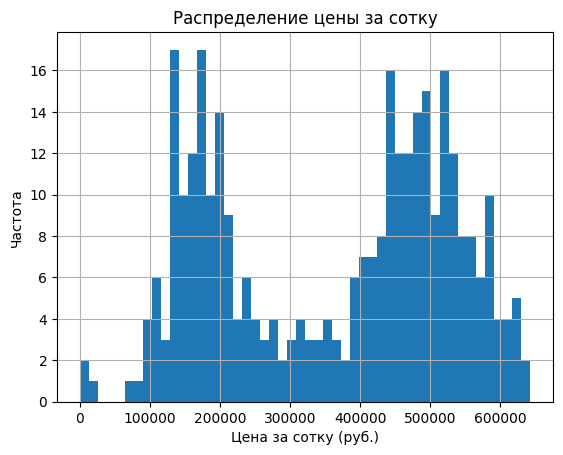

In [9]:
import numpy as np
import matplotlib.pyplot as plt
# 1) Цена за сотку (100 м²)
blocks_pred["land_value_per_100m2"] = blocks_pred["land_value"] / blocks_pred["site_area"] * 100

# 2) Заменяем inf на NaN
blocks_pred = blocks_pred.replace([np.inf, -np.inf], np.nan)
blocks_pred = blocks_pred.fillna(0)

# 3) Удаляем выбросы: оставляем данные до 99-го перцентиля
p99 = blocks_pred["land_value_per_100m2"].quantile(0.95)
blocks_clean = blocks_pred[blocks_pred["land_value_per_100m2"] <= p99].copy()

print(blocks_clean["land_value_per_100m2"].describe())

# 4) Гистограмма после очистки
plt.figure()
blocks_clean["land_value_per_100m2"].dropna().hist(bins=50)
plt.xlabel("Цена за сотку (руб.)")
plt.ylabel("Частота")
plt.title("Распределение цены за сотку")
plt.show()



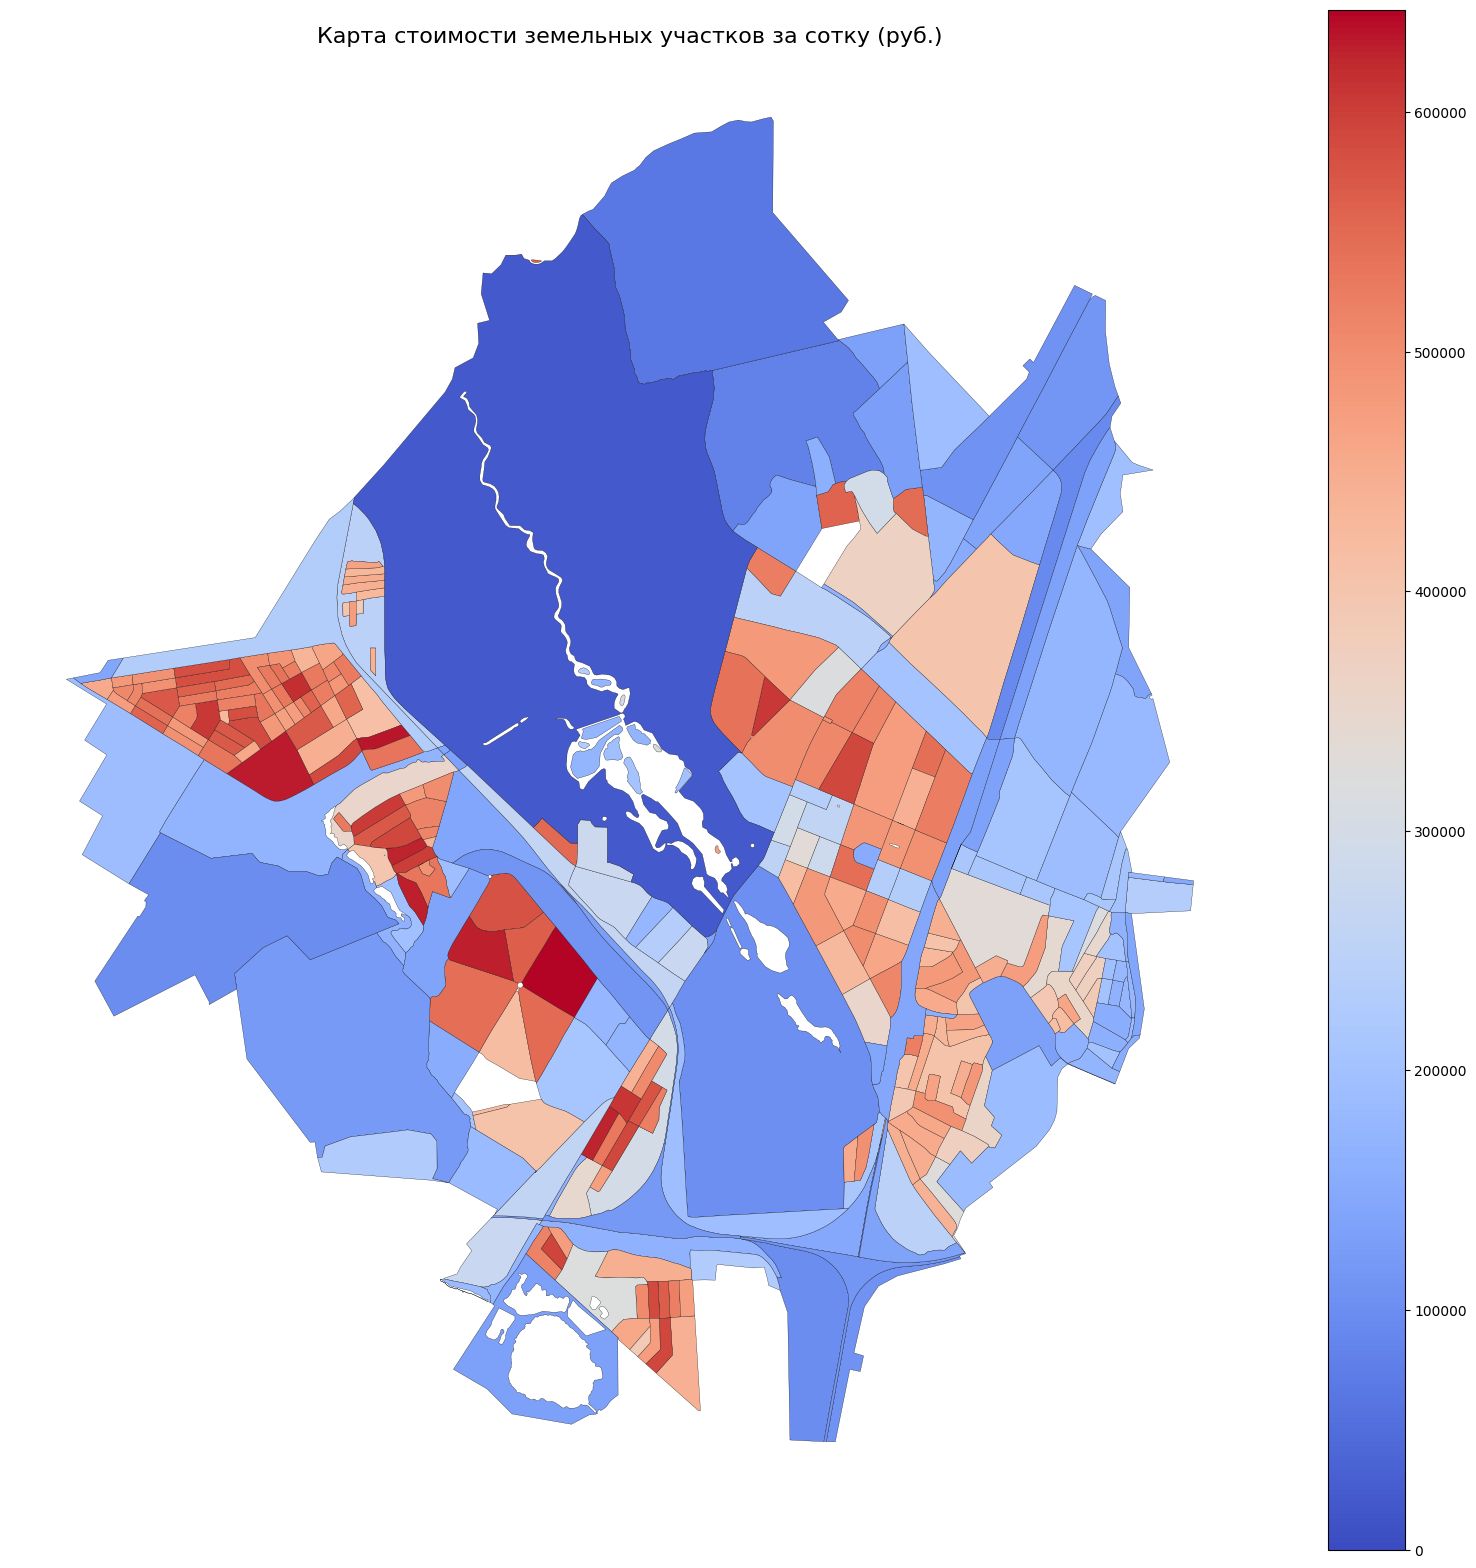

In [10]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value_per_100m2',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков за сотку (руб.)', fontsize=16)

plt.show()

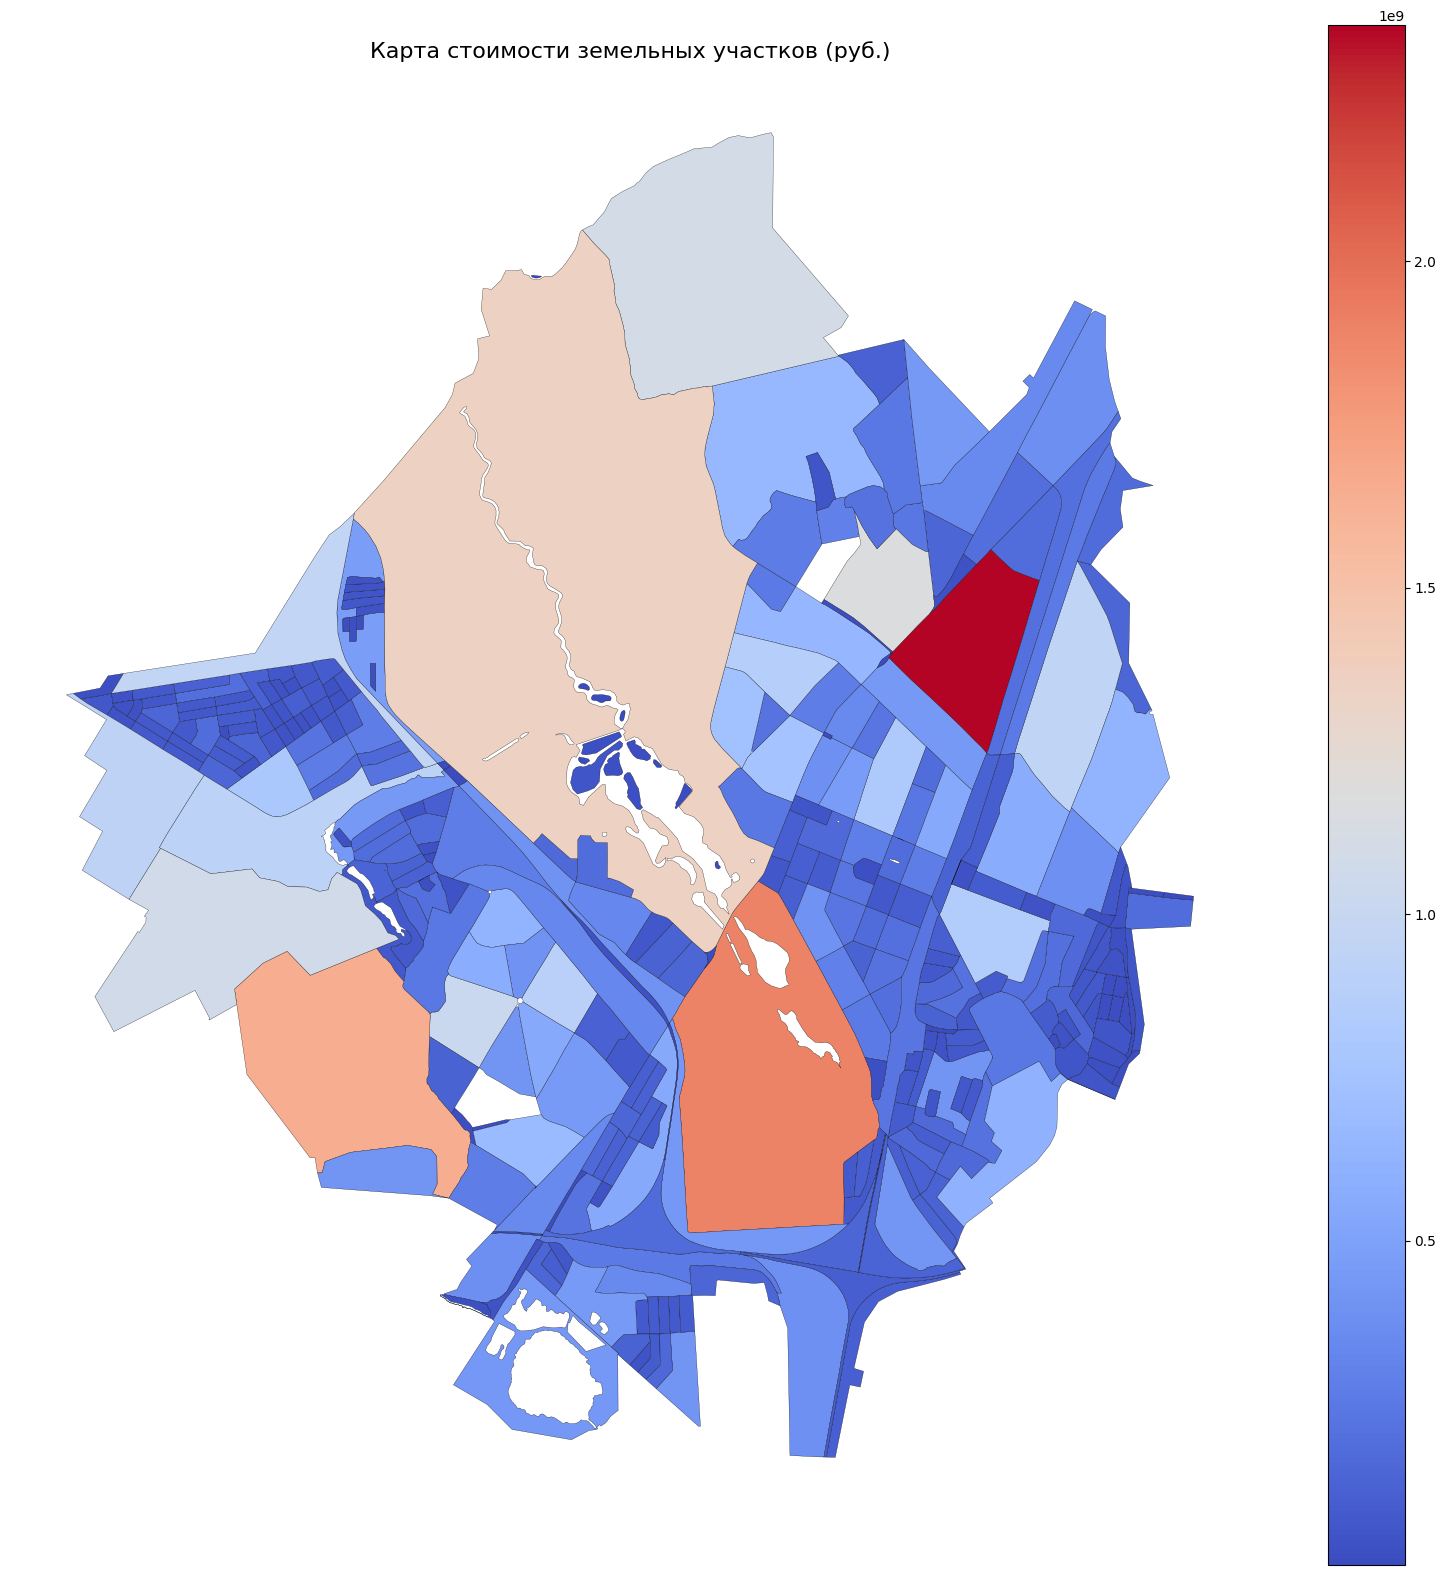

In [11]:
import matplotlib.pyplot as plt

blocks_clean.plot(
    column='land_value',
    legend=True,
    figsize=(20,20),
    cmap='coolwarm',
    edgecolor='black',   # <-- цвет границы
    linewidth=0.2        # <-- толщина границы
).set_axis_off()
plt.title('Карта стоимости земельных участков (руб.)', fontsize=16)

plt.show()

# Выбор сценария развития

In [12]:
blocks_clean["id"] = blocks_clean.index

In [13]:
target_id = 86

/var/folders/p2/g62_fg4547gdlj7_mqyl3nq80000gn/T/ipykernel_5653/4044864446.py:9: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)


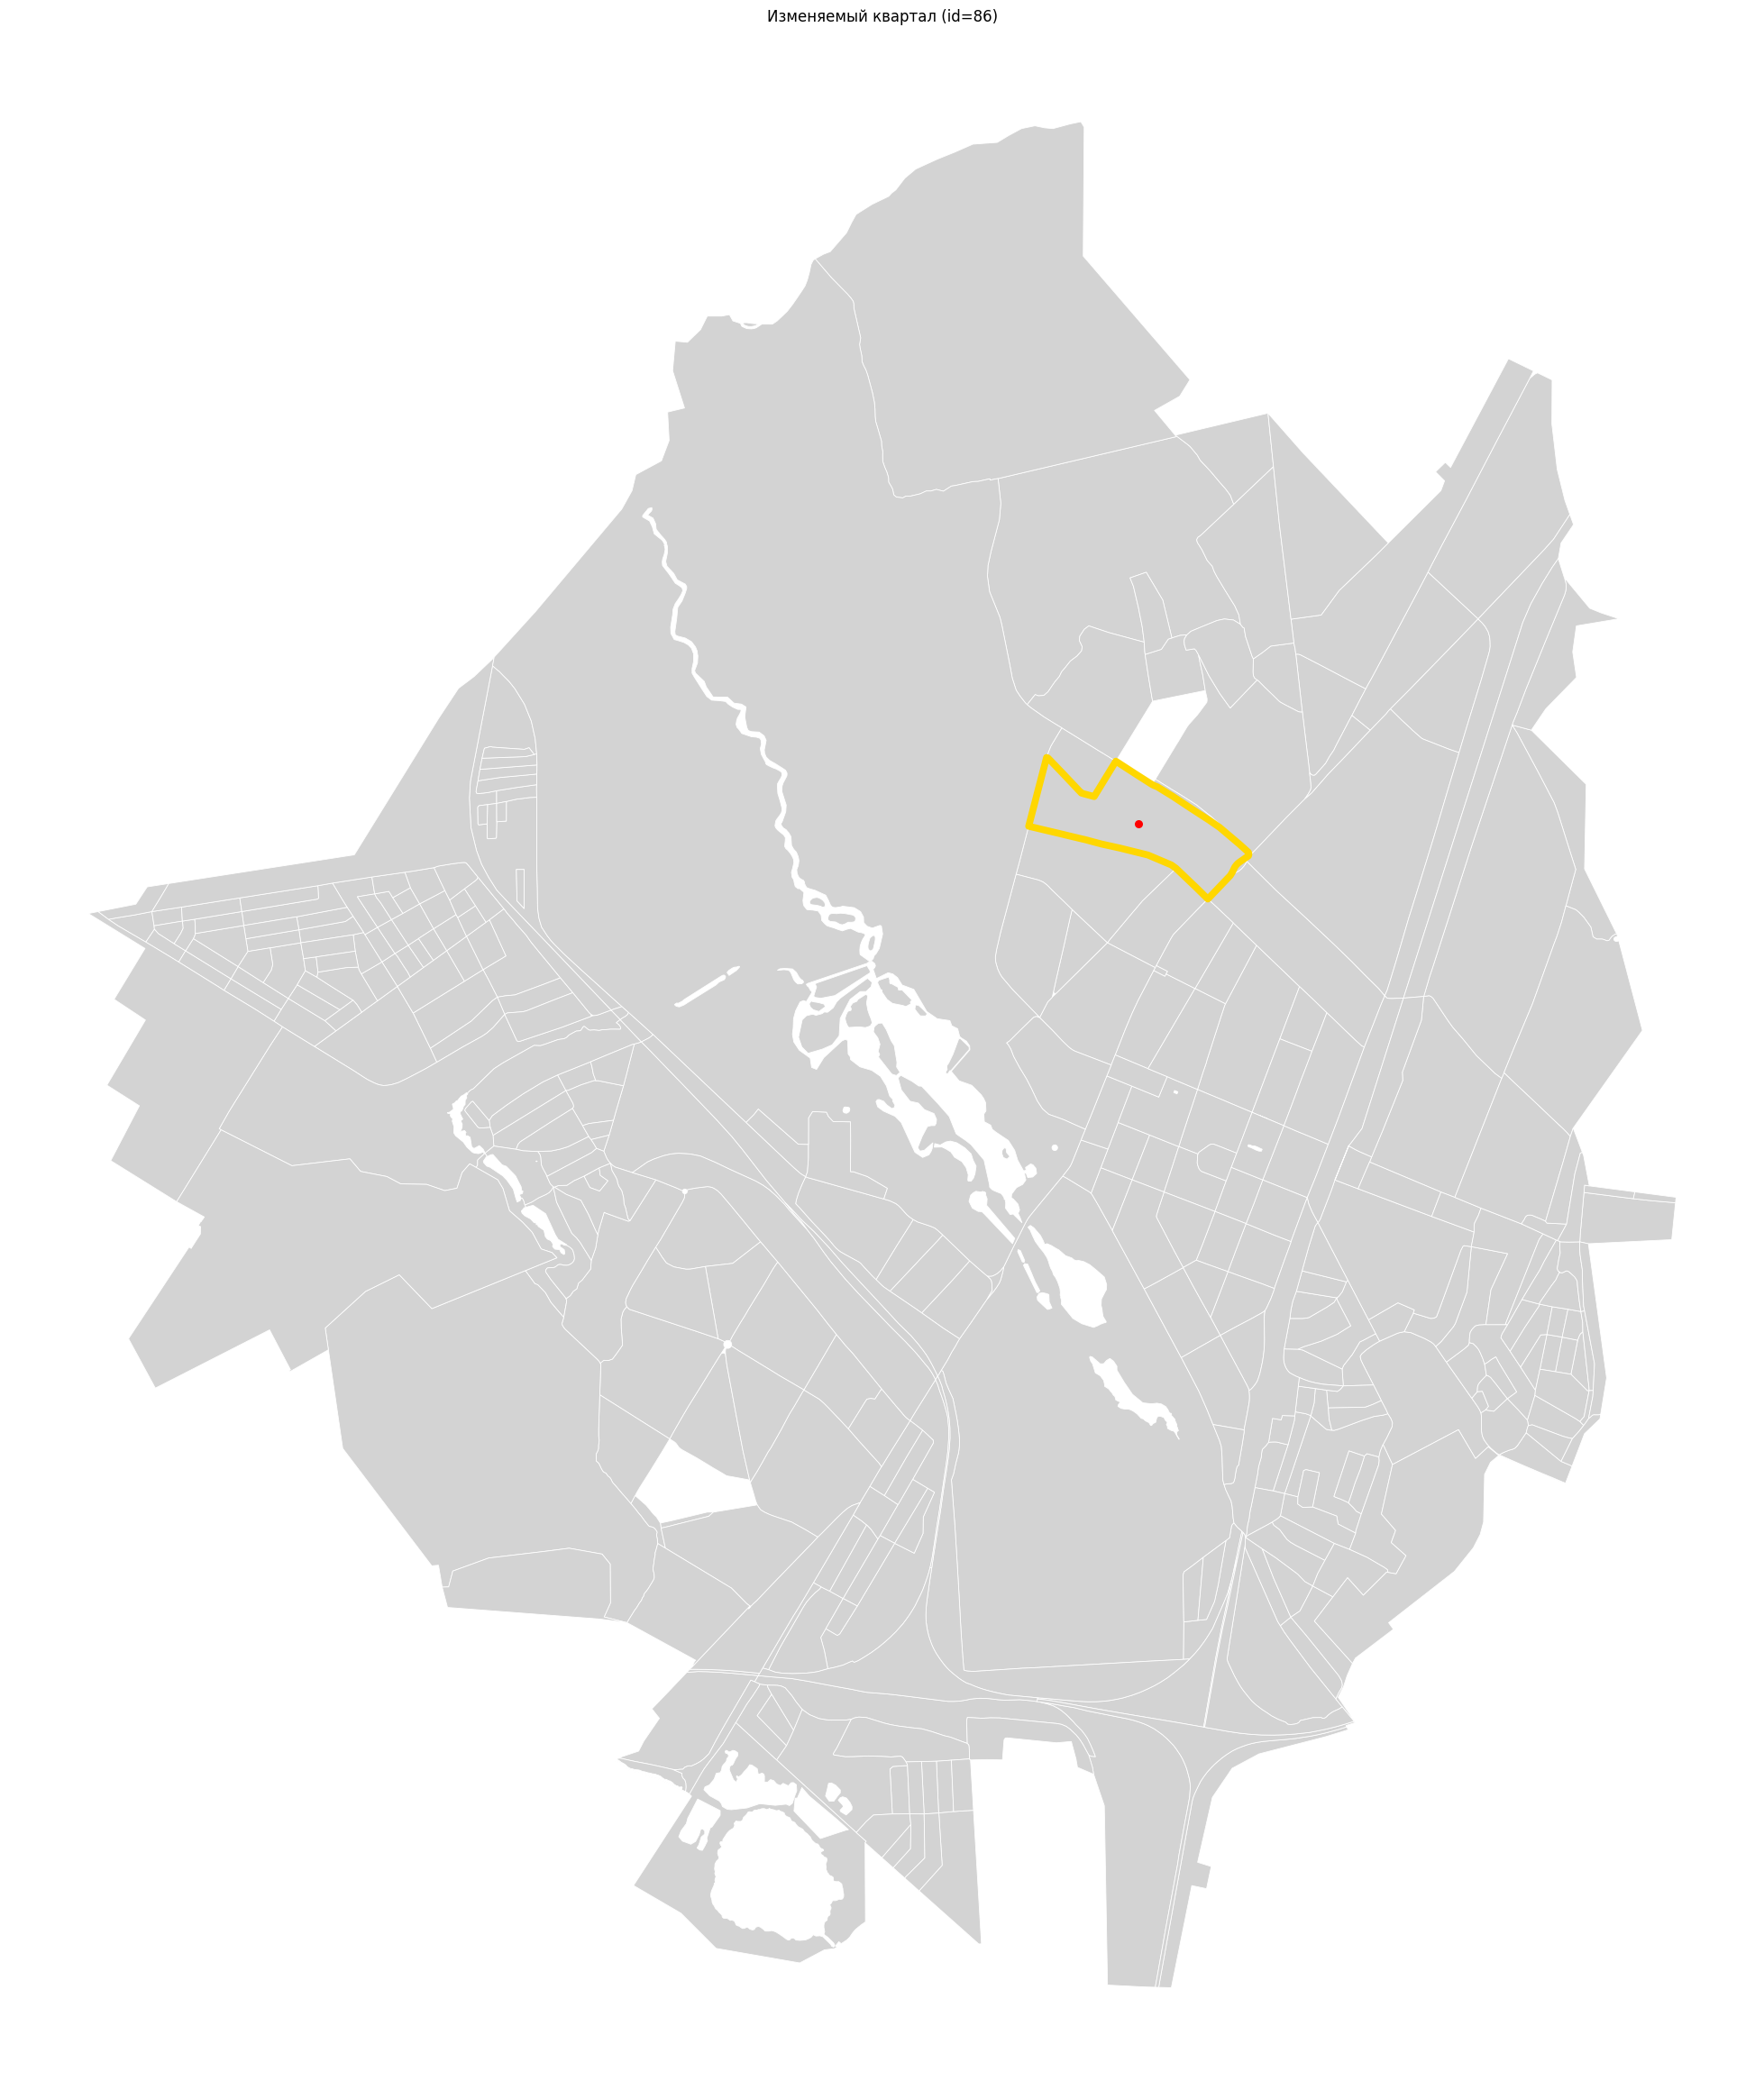

In [14]:
import matplotlib.pyplot as plt

target_id = 86
target_block = blocks_clean.loc[blocks_clean["id"] == target_id]

fig, ax = plt.subplots(figsize=(25, 35))
blocks_clean.plot(ax=ax, color="lightgrey", edgecolor="white", linewidth=0.6)
target_block.plot(ax=ax, color="none", edgecolor="gold", linewidth=5.5)
target_block.centroid.plot(ax=ax, color="red", markersize=30, zorder=3)

ax.set_title(f"Изменяемый квартал (id={target_id})")
ax.axis("off")
plt.show()


In [15]:
# blocks_after.to_file('./data/test/gatchina_RESIDENTIAL.geojson', driver='GeoJSON')

## Оптимизация района

In [16]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from urbanomy.methods.land_value_modeling.ga_mc_optimizer import DistrictProblem

site_area = float(blocks_clean.loc[blocks_clean["id"] == target_id, "site_area"].iloc[0])

problem = DistrictProblem(
    blocks=blocks_clean,
    target_id=target_id,
    model=model,
    
constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    # "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
},
    
    estimator_kwargs={
        "orig_features": numeric_feats+cat_features,
        "categorical_features": cat_features,
    }
)


## NSGA 3

In [17]:
import os
import geopandas as gpd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
os.environ["PATH"] = f"/opt/homebrew/bin:{os.environ['PATH']}"

load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("CHAT_MODEL"),
    base_url=os.getenv("BASE_URL") + "/v1",
    temperature=float(os.getenv("TEMPERATURE", "0")),
    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
)



from urbanomy.methods.land_value_modeling import (
    run_nsga3_with_strategic_alignment,
    build_pareto_front_dataframe,
    )


constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}

res, problem = run_nsga3_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    llm=llm,
    strategic_goals="""
    Основные цели развития Гатчины — cосздание комфортной жилой застройки. 
    """,
    pop_size=20,
    n_gen=30,
    seed=42,
    verbose=True,
    save_history=True,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       21 |      4 |             - |             -
     2 |       42 |      4 |  0.0777602447 |         ideal
     3 |       63 |      4 |  0.0583377015 |         ideal
     4 |       84 |      7 |  0.2581819591 |         ideal
     5 |      105 |      7 |  0.1725224090 |         ideal
     6 |      126 |      3 |  0.3482555059 |         ideal
     7 |      147 |      2 |  3.7066806691 |         ideal
     8 |      168 |      3 |  0.9187907787 |         ideal
     9 |      189 |      6 |  0.8142018833 |         ideal
    10 |      210 |      5 |  0.2667321691 |         nadir
    11 |      231 |      4 |  0.1922027198 |         ideal
    12 |      252 |      3 |  0.2581661973 |         ideal
    13 |      273 |      4 |  0.1444670397 |             f
    14 |      294 |      4 |  0.2859439358 |         ideal
    15 |      315 |      2 |  0.5074727389 |         ideal
    16 |      336 |      3 |  0.3811999389 |         ide

In [20]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.303570e+10,8.418314e+07,7.883314e+09,"{'footprint_area': 26182.57748901136, 'l': 9.8...",0.5,"Сценарий заявлен как RESIDENTIAL, но только 48..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365354e+10,7.020223e+08,7.738202e+09,"{'footprint_area': 25768.945470553113, 'l': 9....",0.5,"Сценарий ориентирован на жилую застройку, но д..."
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.367847e+10,7.269511e+08,6.524878e+09,"{'footprint_area': 25360.687393687887, 'l': 9....",0.5,"Сценарий предусматривает жилую застройку, но т..."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.361952e+10,6.680048e+08,7.868626e+09,"{'footprint_area': 25768.945470553113, 'l': 9....",0.5,"Сценарий предусматривает жилую застройку, но д..."


In [19]:
pareto_df['ser_alignment_reasoning'].dropna().tolist()

['Сценарий заявлен как RESIDENTIAL, но только 48% площади отведено под жильё, а значительная часть – под бизнес (44%) и промышленность (7%). Плотность населения низкая (≈5\u202f000 человек на 262\u202fга), что не обеспечивает компактную и удобную жилую среду. Поэтому соответствие целям комфортной жилой застройки лишь частичное.',
 'Сценарий ориентирован на жилую застройку, но доля бизнес‑ и индустриальных функций высока, а коэффициент озеленения (GSI) низок, что снижает комфорт. Кроме того, тип «высотный советский микрорайон» не полностью соответствует цели создания комфортного жилья.',
 'Сценарий предусматривает жилую застройку, но только 41% площади отведено под жильё, значительная часть – бизнес (≈40%) и промышленность (≈8%). Низкая доля озеленения (GSI\u202f≈\u202f0.1) и тип застройки – высотный советский микрорайон – снижают комфортность, поэтому соответствие целям лишь частичное.',
 'Сценарий предусматривает жилую застройку, но доля жилой функции лишь 48%, а бизнес и промышленнос

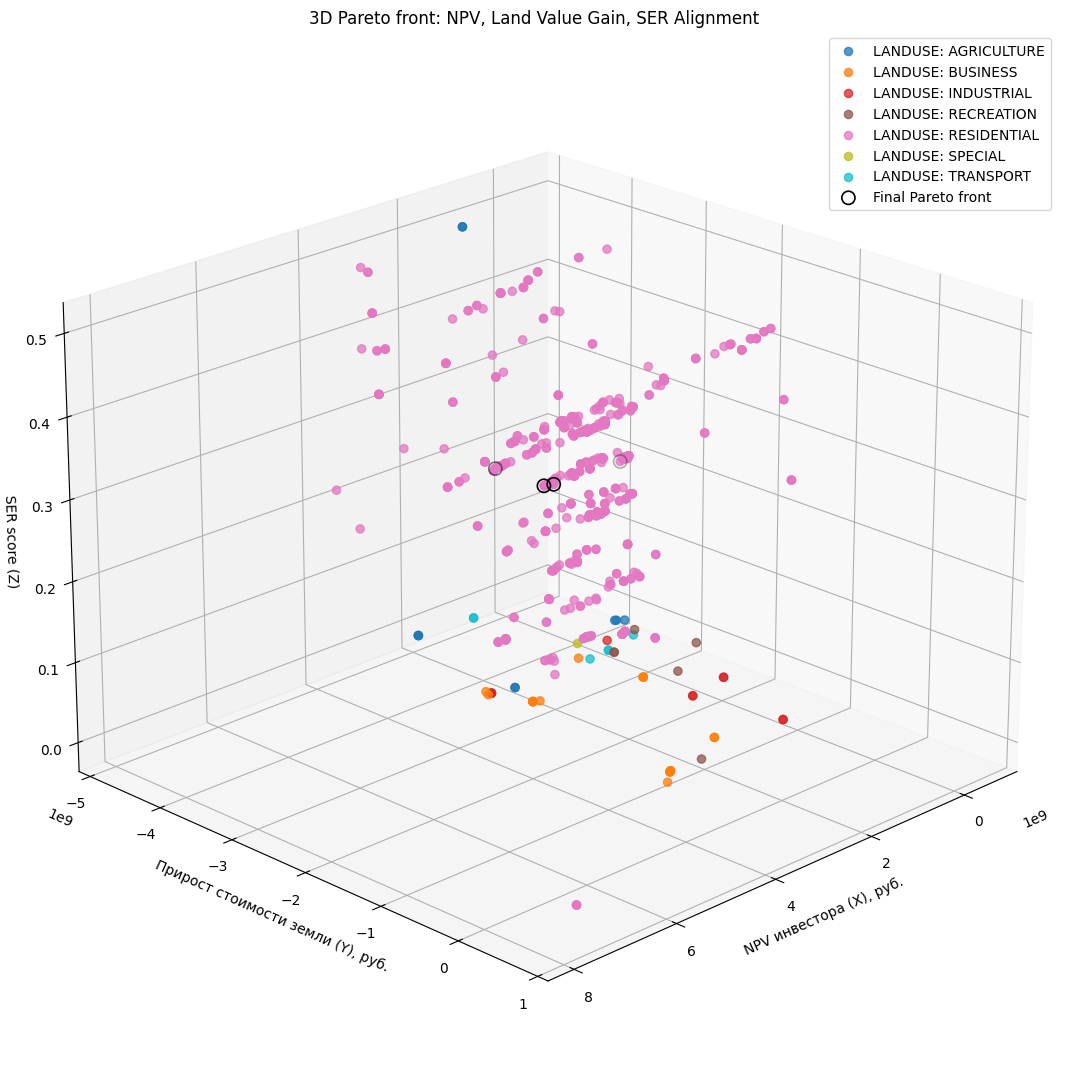

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
pf_z = -res.F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("SER score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


## NSGA 2

In [17]:
import os
import geopandas as gpd
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
os.environ["PATH"] = f"/opt/homebrew/bin:{os.environ['PATH']}"

load_dotenv()

llm = ChatOpenAI(
    model=os.getenv("CHAT_MODEL"),
    base_url=os.getenv("BASE_URL") + "/v1",
    temperature=float(os.getenv("TEMPERATURE", "0")),
    api_key=os.getenv("OPENAI_API_KEY") or "dummy",
)


constraints = {
    "footprint_area": {"type": "float", "min": 0.0, "max": 0.1 * site_area},
    "l": {"type": "float", "min": 1.0, "max": 10.0},
    "mxi": {"type": "float", "min": 0.1, "max": 1.0},

    "residential": {"type": "float", "min": 0.0, "max": 1.0},
    "business": {"type": "float", "min": 0.0, "max": 1.0},
    "recreation": {"type": "float", "min": 0.0, "max": 1.0},
    "industrial": {"type": "float", "min": 0.0, "max": 1.0},
    "transport": {"type": "float", "min": 0.0, "max": 1.0},
    "special": {"type": "float", "min": 0.0, "max": 1.0},
    "agriculture": {"type": "float", "min": 0.0, "max": 1.0},
}




from urbanomy.methods.land_value_modeling import (
    run_nsga2_with_strategic_alignment,
    build_pareto_front_dataframe,
)

res, problem = run_nsga2_with_strategic_alignment(
    blocks=blocks_clean,
    model=model,
    estimator_kwargs={
        "orig_features": numeric_feats + cat_features,
        "categorical_features": cat_features,
    },
    constraints=constraints,
    target_id=target_id,
    llm=llm,
    strategic_goals="""
    Основные цели развития Гатчины — создание комфортной жилой застройки.
    """,
    pop_size=20,
    n_gen=30,
    seed=42,
    verbose=True,
    save_history=True,
)

pareto_df = build_pareto_front_dataframe(res=res, problem=problem)


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      5 |             - |             -
     2 |       40 |     10 |  0.3653456387 |         nadir
     3 |       60 |      5 |  0.2228740856 |         ideal
     4 |       80 |      7 |  0.3668325201 |         ideal
     5 |      100 |     12 |  0.0778862652 |         ideal
     6 |      120 |      1 |  1.004325E+09 |         ideal
     7 |      140 |      3 |  1.0000000000 |         ideal
     8 |      160 |      6 |  0.3686151989 |         ideal
     9 |      180 |      9 |  0.0753321188 |         ideal
    10 |      200 |     10 |  0.0338706698 |         ideal
    11 |      220 |     14 |  0.0937099665 |         ideal
    12 |      240 |      3 |  0.0950760722 |         ideal
    13 |      260 |      6 |  0.2755481277 |         ideal
    14 |      280 |      3 |  4.8357844359 |         nadir
    15 |      300 |      7 |  0.0288127492 |         ideal
    16 |      320 |      5 |  0.0066390996 |         ide

In [21]:
pareto_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365665e+10,7.051281e+08,7.342845e+09,"{'footprint_area': 26153.17730599988, 'l': 9.9...",0.5,"Сценарий объявлен жилым, но только 43% площади..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365459e+10,7.030661e+08,7.345671e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.3,"Жилой участок составляет лишь 43% площади, а з..."
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.380163e+10,8.501151e+08,6.645767e+09,"{'footprint_area': 26218.515324245953, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 41..."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371507e+10,7.635452e+08,7.111336e+09,"{'footprint_area': 26136.385033216895, 'l': 9....",0.3,"Хотя земельный участок отнесён к жилому, тольк..."
4,scenario_4,scenario_4 | RESIDENTIAL,scenario_4 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.377410e+10,8.225807e+08,6.851889e+09,"{'footprint_area': 26154.983702396923, 'l': 9....",0.5,"Хотя участок отнесён к жилой категории, только..."
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.366827e+10,7.167528e+08,7.333057e+09,"{'footprint_area': 26136.816596057815, 'l': 9....",0.5,"Сценарий предусматривает жилую застройку, но т..."
6,scenario_6,scenario_6 | RESIDENTIAL,scenario_6 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.368393e+10,7.324115e+08,7.237215e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.5,"Сценарий объявлен жилым, но только 44,8% площа..."
7,scenario_7,scenario_7 | RESIDENTIAL,scenario_7 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371177e+10,7.602462e+08,6.896353e+09,"{'footprint_area': 26136.435369611885, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 40..."
8,scenario_8,scenario_8 | RESIDENTIAL,scenario_8 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.367883e+10,7.273117e+08,7.243238e+09,"{'footprint_area': 26152.732635511984, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 42..."
9,scenario_9,scenario_9 | RESIDENTIAL,scenario_9 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365816e+10,7.066380e+08,7.335286e+09,"{'footprint_area': 26167.469326830047, 'l': 9....",0.4,"Сценарий заявлен как RESIDENTIAL, но только 43..."


In [18]:
pareto_df['ser_alignment_reasoning'].dropna().tolist()

['Сценарий объявлен жилым, но только 43% площади отведено под жильё, значительная часть – бизнес, промышленность и транспорт – противоречит цели комфортной жилой застройки; при этом тип застройки (высотный советский микрорайон) не гарантирует высокий уровень комфорта.',
 'Жилой участок составляет лишь 43% площади, а значительная часть отведена под бизнес (38%) и промышленность (13%). Плотность населения низкая (≈4,5 тыс. человек на 262\u202fтыс.\u202fм²) и доминирует тип застройки «высотный советский микрорайон», что не способствует созданию комфортной жилой среды.',
 'Сценарий заявлен как RESIDENTIAL, но только 41% площади отведено под жильё, остальные значительные доли – бизнес, промышленность и транспорт, что снижает комфортность. Кроме того, тип «high-rise soviet microdistrict» обычно не соответствует современным требованиям комфортного жилья.',
 'Хотя земельный участок отнесён к жилому, только 40% площади отведено под жильё, а значительная часть – под бизнес (35%) и промышленность

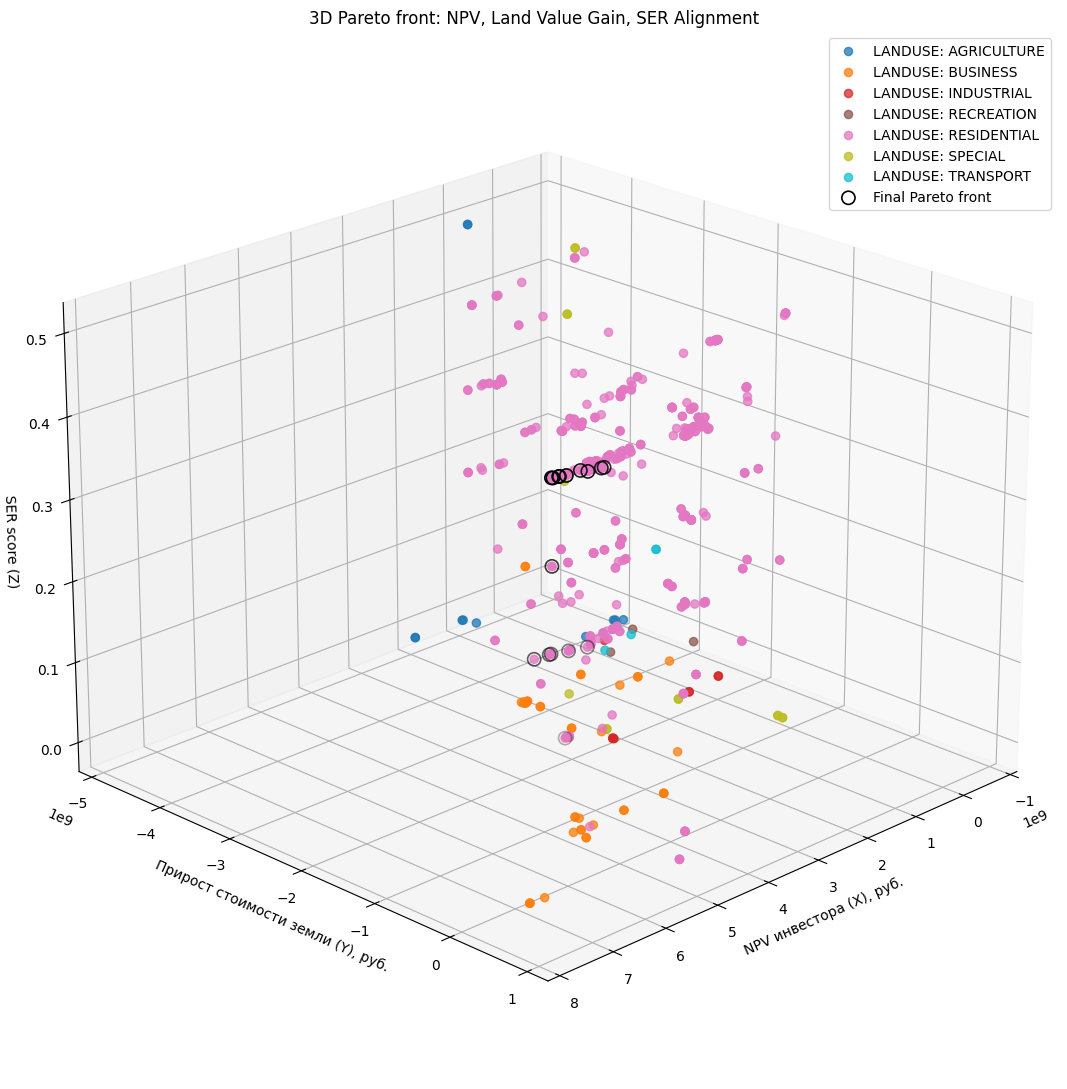

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем все решения из history, иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]
ser_score = -F[:, 2]

# 4) LANDUSE для каждого решения
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

# 6) 3D-график
fig = plt.figure(figsize=(11, 11))
ax = fig.add_subplot(111, projection="3d")

for lu in unique_lu:
    m = landuse_labels == lu
    ax.scatter(
        investor_npv[m],
        admin_gain[m],
        ser_score[m],
        s=35,
        alpha=0.75,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# 7) Отдельно выделяем финальный Pareto front из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
pf_z = -res.F[:, 2]

ax.scatter(
    pf_x,
    pf_y,
    pf_z,
    s=90,
    c="none",
    edgecolors="black",
    linewidths=1.2,
    label="Final Pareto front",
)

ax.set_xlabel("NPV инвестора (X), руб.")
ax.set_ylabel("Прирост стоимости земли (Y), руб.")
ax.set_zlabel("SER score (Z)")
ax.set_title("3D Pareto front: NPV, Land Value Gain, SER Alignment")

ax.view_init(elev=22, azim=45)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


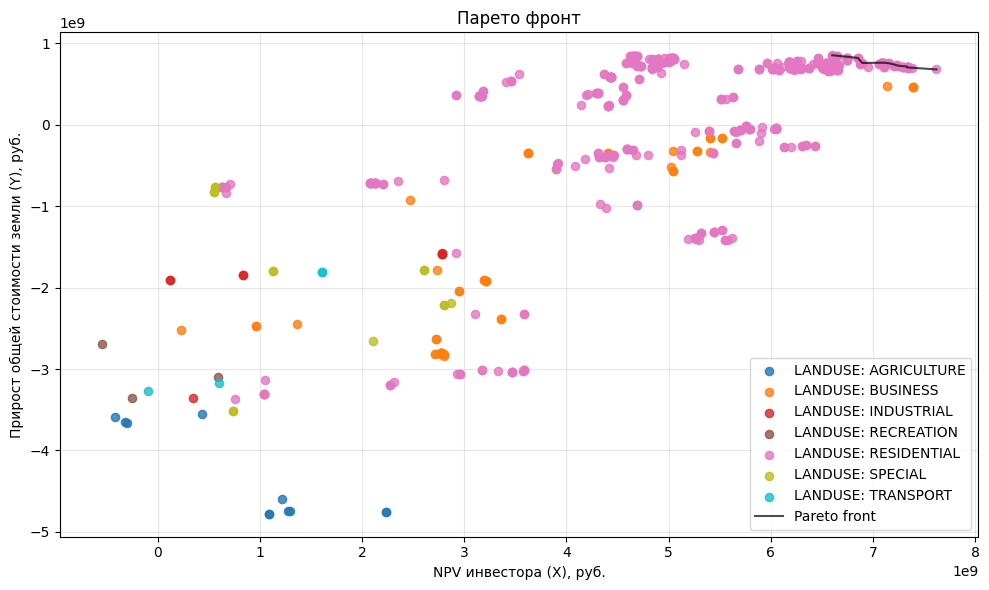

In [20]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   

# NSGA 2(2 критерия)

In [17]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize

algorithm = NSGA2(
    pop_size=20,
    eliminate_duplicates=True,
)

res = minimize(
    problem,
    algorithm,
    ('n_gen', 30),
    seed=42,
    verbose=True,
    save_history=True,
)

n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |       20 |      2 |             - |             -
     2 |       40 |      4 |  0.0290188786 |             f
     3 |       60 |      7 |  0.1993080825 |         ideal
     4 |       80 |      4 |  0.0816176823 |         ideal
     5 |      100 |      2 |  1.0064494217 |         ideal
     6 |      120 |      2 |  1.844033E+01 |         ideal
     7 |      140 |      2 |  0.9756397487 |         ideal
     8 |      160 |      2 |  0.2794573753 |         ideal
     9 |      180 |      5 |  0.8232373236 |         ideal
    10 |      200 |      3 |  0.7092275666 |         ideal
    11 |      220 |      9 |  0.0071206440 |         ideal
    12 |      240 |      7 |  0.0499500510 |         ideal
    13 |      260 |      8 |  0.1214455105 |         ideal
    14 |      280 |      6 |  0.1060155591 |         ideal
    15 |      300 |      5 |  0.3778818222 |         ideal
    16 |      320 |      4 |  0.3672532208 |         ide

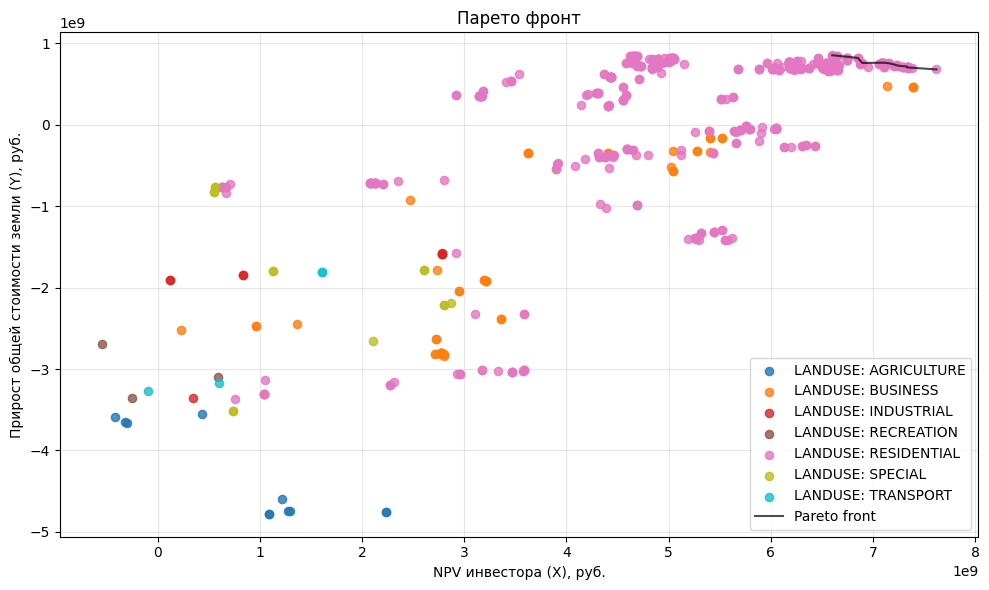

In [24]:
import numpy as np
import matplotlib.pyplot as plt

optimizer = problem

# 1) Базовая стоимость "до"
baseline_land_value = optimizer.evaluate_catboost(
    geonome=optimizer.blocks,
    model=optimizer.model,
    orig_features=optimizer.estimator_kwargs["orig_features"],
    cat_features=optimizer.estimator_kwargs["categorical_features"],
    radius_list=None,
)

# 2) Собираем ВСЕ решения: из history (если optimize(..., save_history=True)), иначе из res.X/res.F
X_all, F_all = [], []
if getattr(res, "history", None):
    for alg in res.history:
        pop = alg.pop
        Xi, Fi = pop.get("X"), pop.get("F")
        if Xi is not None and Fi is not None and len(Xi):
            X_all.append(np.asarray(Xi))
            F_all.append(np.asarray(Fi))

if X_all:
    X = np.vstack(X_all)
    F = np.vstack(F_all)
else:
    X = np.asarray(res.X)
    F = np.asarray(res.F)

# 3) Цели
land_value_total = -F[:, 0]
admin_gain = land_value_total - baseline_land_value
investor_npv = -F[:, 1]

# 4) LANDUSE для каждого решения (через тот же repair, что в оптимизаторе)
landuse_labels = []
for genome_vec in X:
    changes = {name: genome_vec[j] for j, name in enumerate(optimizer.var_names)}
    repaired = optimizer._repair_genome(changes)   # использует логику из вашей задачи
    lu = repaired["land_use"]
    lu_name = getattr(lu, "name", str(lu).split(".")[-1])
    landuse_labels.append(lu_name)

landuse_labels = np.array(landuse_labels)
unique_lu = np.unique(landuse_labels)

# 5) Цвета + легенда
cmap = plt.get_cmap("tab10", len(unique_lu))
color_map = {lu: cmap(i) for i, lu in enumerate(unique_lu)}

plt.figure(figsize=(10, 6))

for lu in unique_lu:
    m = landuse_labels == lu
    plt.scatter(
        investor_npv[m],
        admin_gain[m],
        s=35,
        alpha=0.8,
        color=color_map[lu],
        label=f"LANDUSE: {lu}",
    )

# (опционально) поверх — линия самого Pareto-фронта из res.F
pf_x = -res.F[:, 1]
pf_y = -res.F[:, 0] - baseline_land_value
order = np.argsort(pf_x)
plt.plot(pf_x[order], pf_y[order], color="black", lw=1.5, alpha=0.7, label="Pareto front")

plt.xlabel("NPV инвестора (X), руб.")
plt.ylabel("Прирост общей стоимости земли (Y), руб.")
plt.title("Парето фронт")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()   


In [29]:
from urbanomy.methods.land_value_modeling import (
    build_pareto_front_dataframe,
)

pareto_front_df = build_pareto_front_dataframe(
    res=res,
    problem=problem,
    use_history=False,                        # True если хочешь взять все решения из history
    scenario_prefix="scenario",
)
pareto_front_df

,scenario_id,title,summary,land_use,land_value_after,land_value_gain,investor_npv,params_repaired,ser_alignment_score,ser_alignment_reasoning
0,scenario_0,scenario_0 | RESIDENTIAL,scenario_0 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365665e+10,7.051281e+08,7.342845e+09,"{'footprint_area': 26153.17730599988, 'l': 9.9...",0.5,"Сценарий объявлен жилым, но только 43% площади..."
1,scenario_1,scenario_1 | RESIDENTIAL,scenario_1 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365459e+10,7.030661e+08,7.345671e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.3,"Жилой участок составляет лишь 43% площади, а з..."
2,scenario_2,scenario_2 | RESIDENTIAL,scenario_2 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.380163e+10,8.501151e+08,6.645767e+09,"{'footprint_area': 26218.515324245953, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 41..."
3,scenario_3,scenario_3 | RESIDENTIAL,scenario_3 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371507e+10,7.635452e+08,7.111336e+09,"{'footprint_area': 26136.385033216895, 'l': 9....",0.3,"Хотя земельный участок отнесён к жилому, тольк..."
4,scenario_4,scenario_4 | RESIDENTIAL,scenario_4 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.377410e+10,8.225807e+08,6.851889e+09,"{'footprint_area': 26154.983702396923, 'l': 9....",0.5,"Хотя участок отнесён к жилой категории, только..."
5,scenario_5,scenario_5 | RESIDENTIAL,scenario_5 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.366827e+10,7.167528e+08,7.333057e+09,"{'footprint_area': 26136.816596057815, 'l': 9....",0.5,"Сценарий предусматривает жилую застройку, но т..."
6,scenario_6,scenario_6 | RESIDENTIAL,scenario_6 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.368393e+10,7.324115e+08,7.237215e+09,"{'footprint_area': 26152.773554856834, 'l': 9....",0.5,"Сценарий объявлен жилым, но только 44,8% площа..."
7,scenario_7,scenario_7 | RESIDENTIAL,scenario_7 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.371177e+10,7.602462e+08,6.896353e+09,"{'footprint_area': 26136.435369611885, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 40..."
8,scenario_8,scenario_8 | RESIDENTIAL,scenario_8 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.367883e+10,7.273117e+08,7.243238e+09,"{'footprint_area': 26152.732635511984, 'l': 9....",0.5,"Сценарий заявлен как RESIDENTIAL, но только 42..."
9,scenario_9,scenario_9 | RESIDENTIAL,scenario_9 | RESIDENTIAL; land_use=RESIDENTIAL...,RESIDENTIAL,6.365816e+10,7.066380e+08,7.335286e+09,"{'footprint_area': 26167.469326830047, 'l': 9....",0.4,"Сценарий заявлен как RESIDENTIAL, но только 43..."


In [19]:
# print("Лучшие решения (переменные):\n", res.X) # Массив решений на фронте Парето
# print("Значения целевых функций:\n", -res.F)


In [26]:
len(res.opt)

16

In [21]:
# params_optimal = {param: res.X[3][i] for i, param in enumerate(problem.constraints.keys())}
# params_optimal

In [27]:
idx = np.argmin(res.F[:, 0])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 26213.666720194065,
  'l': 9.796012234576096,
  'mxi': 0.3277231623649504,
  'residential': 0.409653952956188,
  'business': 0.3259864323346888,
  'recreation': 0.012630596554359644,
  'industrial': 0.12114359829585881,
  'transport': 0.1295196896321495,
  'special': 0.0007601965477314515,
  'agriculture': 0.0003055336790239366,
  'share': 0.409653952956188,
  'land_use': <LandUse.RESIDENTIAL: 'residential'>,
  'build_floor_area': 256789.39990412132,
  'living_area': 84155.83419837654,
  'non_living_area': 172633.56570574478,
  'population': 4207.791709918827,
  'fsi': 0.9791742250934645,
  'gsi': 0.09995641100134216,
  'morphotype': 'high-rise soviet microdistrict'},
 'land_value_after': 63806683279.0634,
 'land_value_gain': 855163365.374466,
 'investor_npv': 6602130134.58}

In [28]:
idx = np.argmin(res.F[:, 1])   # максимум land_value

params_optimal = {p: res.X[idx][i] for i, p in enumerate(problem.constraints.keys())}
params_repaired = problem._repair_genome(params_optimal)

metrics = {
    "params_repaired": params_repaired,
    "land_value_after": float(-res.F[idx, 0]),
    "land_value_gain": float(-res.F[idx, 0] - baseline_land_value),
    "investor_npv": float(-res.F[idx, 1]),
}
metrics

{'params_repaired': {'footprint_area': 26167.519663225048,
  'l': 9.990358153200255,
  'mxi': 0.35244732102867427,
  'residential': 0.4405591512858428,
  'business': 0.4123422968211029,
  'recreation': 0.00512800325580536,
  'industrial': 0.12554241538164448,
  'transport': 0.016013599461073936,
  'special': 2.145670110085465e-05,
  'agriculture': 0.00039307709342944997,
  'share': 0.4405591512858428,
  'land_use': <LandUse.RESIDENTIAL: 'residential'>,
  'build_floor_area': 261422.89341652836,
  'living_area': 92137.79844022007,
  'non_living_area': 169285.0949763083,
  'population': 4606.889922011003,
  'fsi': 0.9968423898276038,
  'gsi': 0.0997804457599231,
  'morphotype': 'high-rise soviet microdistrict'},
 'land_value_after': 63632470556.56209,
 'land_value_gain': 680950642.8731537,
 'investor_npv': 7622466346.02}

# Визуализация прироста стоимости земли

Изменение стоимости земли по всем кварталам:
 • Сумма до:    62 951 519 914 ₽
 • Сумма после: 63 678 471 021 ₽
 • Изм.  ₽:     +726 951 108 ₽
 • Изм., %:     +1.15%

Изменяемый квартал:
 • До: 590 959 314 ₽ | После: 898 952 429 ₽ | Δ: +307 993 115 ₽ | Δ%: +52.12%


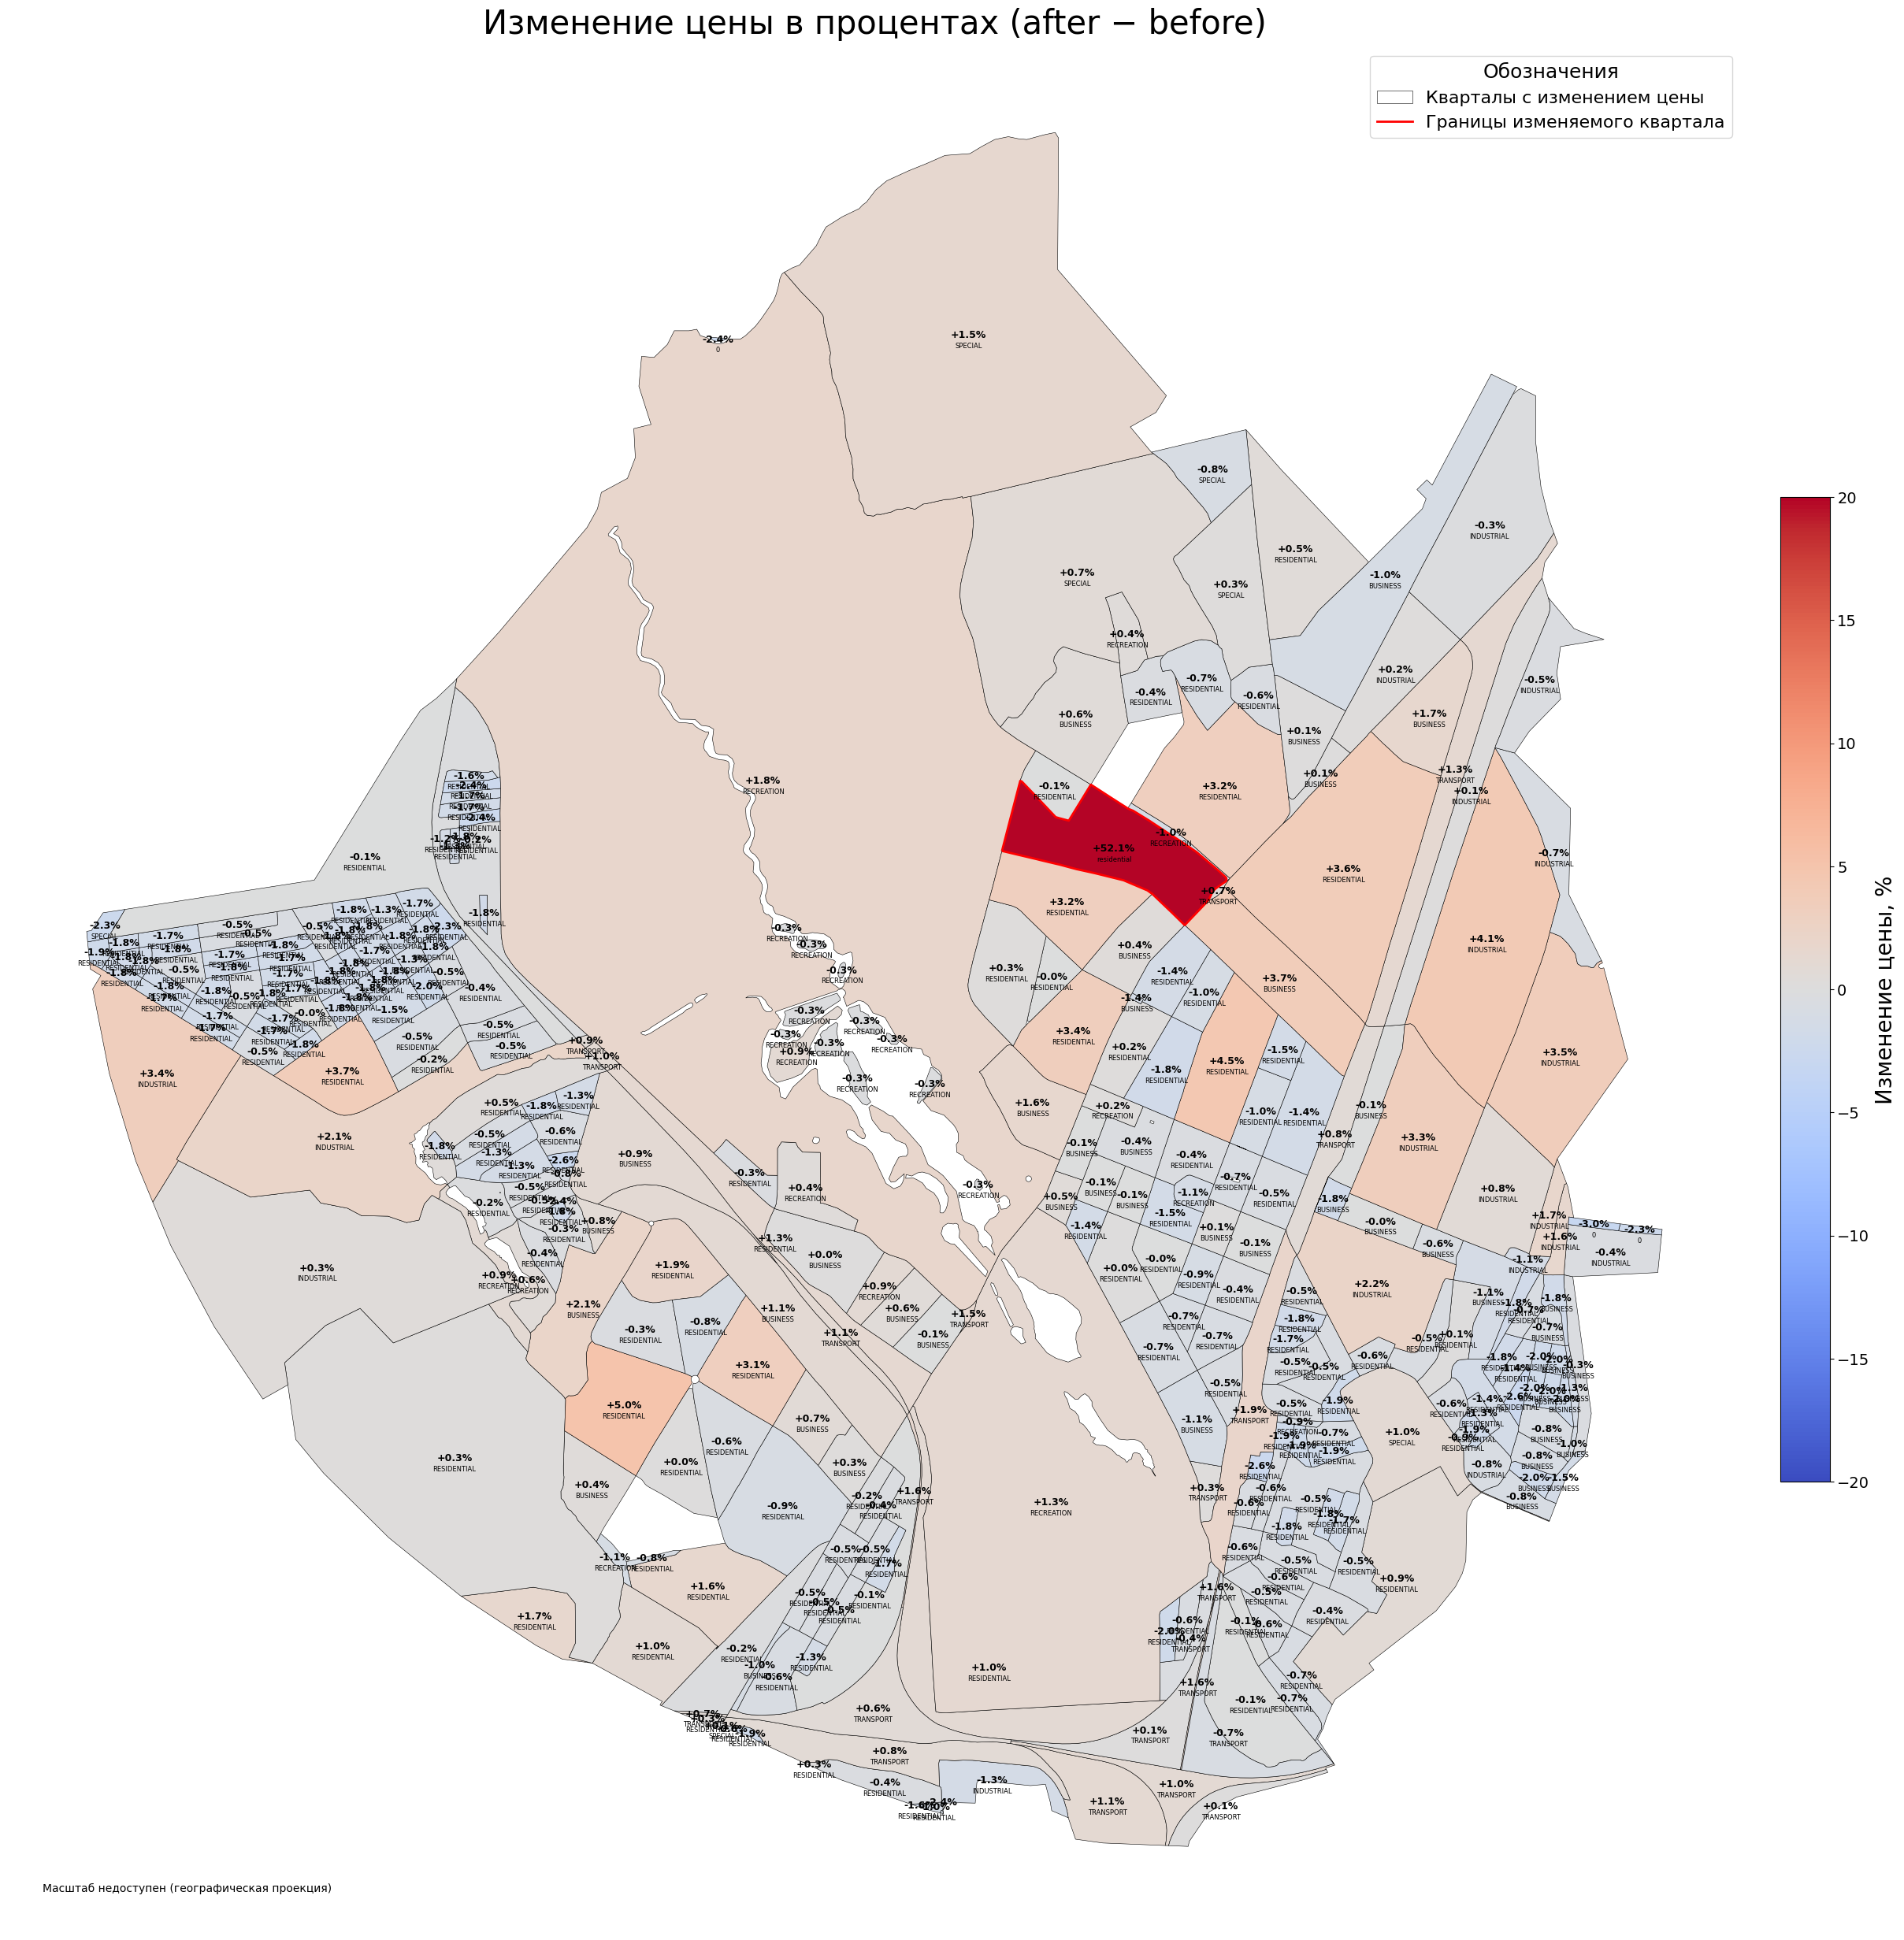

In [26]:
import numpy as np
import pandas as pd

from urbanomy.methods.land_value_modeling import (
    ScenarioTEPModifier,
    LandPriceEstimator,
    plot_scenario_impact,
)


# Базовые кварталы должны быть теми же, что использовал оптимизатор
blocks_before = problem.blocks.copy()

# Помечаем проектный квартал
blocks_before["is_project"] = False
blocks_before.loc[blocks_before["id"] == target_id, "is_project"] = True

# 1) Применяем оптимизационный сценарий к базовым кварталам
modifier = ScenarioTEPModifier(blocks_before)
blocks_after = modifier.apply(target_id, params_repaired)
blocks_after["is_project"] = False
blocks_after.loc[blocks_after["id"] == target_id, "is_project"] = True

# 2) Считаем стоимость "до" и "после" тем же способом, что и в DistrictProblem
estimator_kwargs = dict(
    model=problem.model,
    orig_features=problem.estimator_kwargs["orig_features"],
    categorical_features=problem.estimator_kwargs["categorical_features"],
    use_service_features=False,
)

baseline_estimator = LandPriceEstimator(
    blocks=blocks_before,
    **estimator_kwargs,
)
blocks_before_pred = baseline_estimator.predict()

scenario_estimator = LandPriceEstimator(
    blocks=blocks_after,
    **estimator_kwargs,
)
blocks_after_pred = scenario_estimator.predict()

for df in (blocks_before_pred, blocks_after_pred):
    df["land_value_per_100m2"] = np.where(
        pd.to_numeric(df["site_area"], errors="coerce") > 0,
        pd.to_numeric(df["land_value"], errors="coerce")
        / pd.to_numeric(df["site_area"], errors="coerce") * 100,
        np.nan,
    )

baseline_cols = blocks_before_pred[
    ["id", "land_value", "land_value_per_100m2"]
].rename(
    columns={
        "land_value": "land_value_before",
        "land_value_per_100m2": "land_value_before_per_100m2",
    }
)

blocks_full_value = blocks_after_pred.merge(
    baseline_cols,
    on="id",
    how="left",
    validate="one_to_one",
)

blocks_full_value["d_rub"] = (
    blocks_full_value["land_value"] - blocks_full_value["land_value_before"]
)

blocks_full_value["land_value_delta_pct"] = np.where(
    pd.to_numeric(blocks_full_value["land_value_before"], errors="coerce") > 0,
    (blocks_full_value["land_value"] / blocks_full_value["land_value_before"] - 1.0) * 100,
    np.nan,
)

blocks_full_value = blocks_full_value.replace([np.inf, -np.inf], np.nan)

sum_before = float(blocks_full_value["land_value_before"].sum())
sum_after = float(blocks_full_value["land_value"].sum())
sum_delta = sum_after - sum_before
sum_delta_pct = (sum_after / sum_before - 1.0) * 100 if sum_before > 0 else np.nan

print("Изменение стоимости земли по всем кварталам:")
print(f" • Сумма до:    {sum_before:,.0f} ₽".replace(",", " "))
print(f" • Сумма после: {sum_after:,.0f} ₽".replace(",", " "))
print(f" • Изм., ₽:     {sum_delta:+,.0f} ₽".replace(",", " "))
print(f" • Изм., %:     {sum_delta_pct:+.2f}%")

target_row = blocks_full_value.loc[blocks_full_value["id"] == target_id].iloc[0]
print("\nИзменяемый квартал:")
print(
    f" • До: {target_row['land_value_before']:,.0f} ₽ | "
    f"После: {target_row['land_value']:,.0f} ₽ | "
    f"Δ: {target_row['d_rub']:+,.0f} ₽ | "
    f"Δ%: {target_row['land_value_delta_pct']:+.2f}%".replace(",", " ")
)

scenario_result = plot_scenario_impact(
    blocks=blocks_full_value,
    target_idx=target_id,
    target_id_column="id",
    print_summary=False,
    print_quarter_stats=False,
    figsize=(25, 35),
)



# Инвестиционная привлекательность

In [23]:
blocks_full_value.loc[blocks_full_value["id"] == 86].iloc[0]

residential                                                             0.996658
business                                                                0.003342
recreation                                                                   0.0
industrial                                                                   0.0
transport                                                                    0.0
special                                                                      0.0
agriculture                                                                  0.0
land_use                                                     LandUse.RESIDENTIAL
share                                                                   0.996658
footprint_area                                                      26168.673099
build_floor_area                                                    261609.12262
living_area                                                        208587.863272
non_living_area             

In [24]:
from urbanomy.methods.investment_potential import calculate_investment_metrics

summary = calculate_investment_metrics(blocks_full_value)
summary.head()

Project totals:
 • Land area:          262,250.98
 • Built area:         261,609.12
 • Land value:         590,959,314.48
 • Demolition cost:    96,396,921.16
 • Construction cost:  12,302,623,111.36
 • Investment need:    12,989,979,347.01
 • Project NPV:        7,264,713,973.68
 • Project IRR:        0.34
 • Project PI:         1.65
 • Project PP (yrs):   5.46


,land_use,land_area,built_area,land_value,demolition_cost,construction_cost,investment_need,NPV,IRR,PI,PP_years,EI
0,LandUse.RESIDENTIAL,262250.98,261609.12,5.909593e+08,96396921.16,1.230262e+10,1.298998e+10,7.264714e+09,0.34,1.65,5.46,100.0


# LLM 1